# Meridionally Equidistant Polyconic Projection

Meridionally Equidistant Polyconic Projection is a map projection that produces a world map with an inverted teardrop-shaped outline.
This projection was designed to address a known limitation of the American polyconic projection, in which the total length of meridians increases as one moves away from the central meridian. While mitigating this meridional distortion, the projection preserves the regularity of parallels in a polyconic-like geometric framework.

The projection was developed by Donghwi Park during his Ph.D. coursework period in 2019, but was not formally published at that time.

tempsum = 180.0


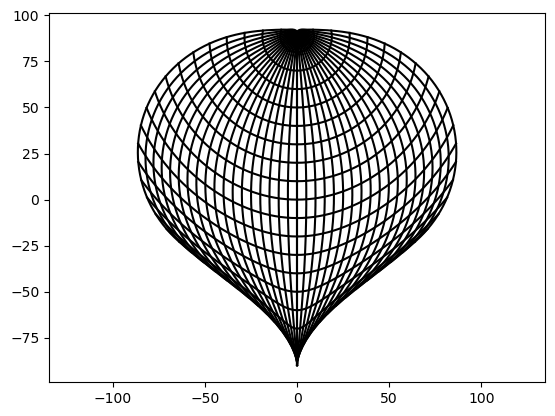

In [50]:
import numpy as np
import matplotlib.pyplot as plt

# degree-based trig functions
def sind(x):
    return np.sin(np.deg2rad(x))

def cosd(x):
    return np.cos(np.deg2rad(x))

# MATLAB 코드의 B+1 접근을 안전하게 처리하기 위해 열을 하나 더 둠
# 원래 의미상 주 계산 영역은 [:, :361]
X = np.zeros((181, 362))
Y = np.zeros((181, 362))

# Y(1,:) = 90;
Y[0, :] = 90

# for A=0:1:360
#   X(2,A+1)=sind(A/2);
#   Y(2,A+1)=90-cosd(A/2);
for A in range(0, 361):
    X[1, A] = sind(A / 2)
    Y[1, A] = 90 - cosd(A / 2)

# for A=0:1:180
#   Y(A+1,1)=90-A;
for A in range(0, 181):
    Y[A, 0] = 90 - A

nerbi = cosd(0.25) * sind(0.25) / (1 - cosd(1))

# MATLAB:
# for A=2:1:180
#   tempnerbi=nerbi*(cosd(A)-cosd(A+1));
#   for B=1:1:360
#       ...
#       X(A+1,B+1)=...
#       Y(A+1,B+1)=...
#   end
# end
#
# Python index 대응:
# MATLAB A = 2..180  <->  Python a = 1..179
# MATLAB B = 1..360  <->  Python b = 0..359
for a in range(1, 180):
    A_mat = a + 1
    tempnerbi = nerbi * (cosd(A_mat) - cosd(A_mat + 1))

    for b in range(0, 360):
        tempnerbi2 = tempnerbi + (
            (Y[a + 1, b] - Y[a, b]) * (X[a, b + 1] - X[a, b])
            - (Y[a, b + 1] - Y[a, b]) * (X[a + 1, b] - X[a, b])
        )

        dx_diag = X[a + 1, b] - X[a, b + 1]
        dy_diag = Y[a + 1, b] - Y[a, b + 1]
        templength = np.sqrt(dy_diag**2 + dx_diag**2)

        tempsintheta = tempnerbi2 / templength

        # 수치오차로 1을 살짝 넘는 경우 방지
        tempsintheta = np.clip(tempsintheta, -1.0, 1.0)
        tempcostheta = np.sqrt(1 - tempsintheta**2)

        X[a + 1, b + 1] = X[a, b + 1] + (
            tempcostheta * (X[a + 1, b] - X[a, b + 1])
            - tempsintheta * (Y[a + 1, b] - Y[a, b + 1])
        ) / templength

        Y[a + 1, b + 1] = Y[a, b + 1] + (
            tempsintheta * (X[a + 1, b] - X[a, b + 1])
            + tempcostheta * (Y[a + 1, b] - Y[a, b + 1])
        ) / templength

# plotting에 사용할 실제 영역 (원래 181x361 대응)
Xp = X[:, :361]
Yp = Y[:, :361]

# 길이 검증
tempsum = 0.0
A = 90  # MATLAB 그대로
# MATLAB i=1:180 -> Python i=0:179
for i in range(0, 180):
    # MATLAB X(i+1,A), X(i,A) with 1-based index
    # Python column index = A-1
    col = A - 1
    tempsum += np.sqrt(
        (X[i + 1, col] - X[i, col])**2 +
        (Y[i + 1, col] - Y[i, col])**2
    )

print("tempsum =", tempsum)

# 위선/경선 일부만 다시 그림
for i in range(19):
    r = i * 10
    plt.plot(Xp[r, :], Yp[r, :], color='black')
    plt.plot(-Xp[r, :], Yp[r, :], color='black')

for i in range(19):
    c = i * 20
    plt.plot(Xp[:, c], Yp[:, c], color='black')
    plt.plot(-Xp[:, c], Yp[:, c], color='black')

plt.axis('equal')
plt.show()

tempsum = 180.0


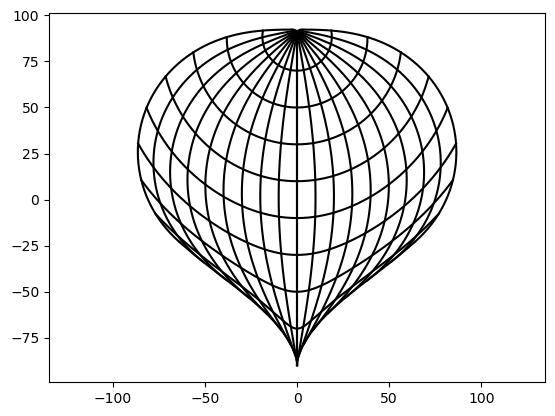

In [52]:
import numpy as np
import matplotlib.pyplot as plt

# degree-based trig functions
def sind(x):
    return np.sin(np.deg2rad(x))

def cosd(x):
    return np.cos(np.deg2rad(x))

# MATLAB 코드의 B+1 접근을 안전하게 처리하기 위해 열을 하나 더 둠
# 원래 의미상 주 계산 영역은 [:, :361]
X = np.zeros((181, 362))
Y = np.zeros((181, 362))

# Y(1,:) = 90;
Y[0, :] = 90

# for A=0:1:360
#   X(2,A+1)=sind(A/2);
#   Y(2,A+1)=90-cosd(A/2);
for A in range(0, 361):
    X[1, A] = sind(A / 2)
    Y[1, A] = 90 - cosd(A / 2)

# for A=0:1:180
#   Y(A+1,1)=90-A;
for A in range(0, 181):
    Y[A, 0] = 90 - A

nerbi = cosd(0.25) * sind(0.25) / (1 - cosd(1))

# MATLAB:
# for A=2:1:180
#   tempnerbi=nerbi*(cosd(A)-cosd(A+1));
#   for B=1:1:360
#       ...
#       X(A+1,B+1)=...
#       Y(A+1,B+1)=...
#   end
# end
#
# Python index 대응:
# MATLAB A = 2..180  <->  Python a = 1..179
# MATLAB B = 1..360  <->  Python b = 0..359
for a in range(1, 180):
    A_mat = a + 1
    tempnerbi = nerbi * (cosd(A_mat) - cosd(A_mat + 1))

    for b in range(0, 360):
        tempnerbi2 = tempnerbi + (
            (Y[a + 1, b] - Y[a, b]) * (X[a, b + 1] - X[a, b])
            - (Y[a, b + 1] - Y[a, b]) * (X[a + 1, b] - X[a, b])
        )

        dx_diag = X[a + 1, b] - X[a, b + 1]
        dy_diag = Y[a + 1, b] - Y[a, b + 1]
        templength = np.sqrt(dy_diag**2 + dx_diag**2)

        tempsintheta = tempnerbi2 / templength

        # 수치오차로 1을 살짝 넘는 경우 방지
        tempsintheta = np.clip(tempsintheta, -1.0, 1.0)
        tempcostheta = np.sqrt(1 - tempsintheta**2)

        X[a + 1, b + 1] = X[a, b + 1] + (
            tempcostheta * (X[a + 1, b] - X[a, b + 1])
            - tempsintheta * (Y[a + 1, b] - Y[a, b + 1])
        ) / templength

        Y[a + 1, b + 1] = Y[a, b + 1] + (
            tempsintheta * (X[a + 1, b] - X[a, b + 1])
            + tempcostheta * (Y[a + 1, b] - Y[a, b + 1])
        ) / templength

# plotting에 사용할 실제 영역 (원래 181x361 대응)
Xp = X[:, :361]
Yp = Y[:, :361]

# MATLAB: plot(X,Y); hold on; plot(-X,Y)
#plt.plot(Xp, Yp, color='black', linewidth=0.7)
#plt.plot(-Xp, Yp, color='black', linewidth=0.7)

# 길이 검증
tempsum = 0.0
A = 90  # MATLAB 그대로
# MATLAB i=1:180 -> Python i=0:179
for i in range(0, 180):
    # MATLAB X(i+1,A), X(i,A) with 1-based index
    # Python column index = A-1
    col = A - 1
    tempsum += np.sqrt(
        (X[i + 1, col] - X[i, col])**2 +
        (Y[i + 1, col] - Y[i, col])**2
    )

print("tempsum =", tempsum)

# 위선/경선 일부만 다시 그림
for i in range(10):
    r = i * 20
    plt.plot(Xp[r, :], Yp[r, :], color='black')
    plt.plot(-Xp[r, :], Yp[r, :], color='black')
for i in range(10):
    c = i * 40
    plt.plot(Xp[:, c], Yp[:, c], color='black')
    plt.plot(-Xp[:, c], Yp[:, c], color='black')

plt.axis('equal')
plt.show()

In [54]:
tempsum = 0.0
A = 40  # MATLAB 그대로
# MATLAB i=1:180 -> Python i=0:179
for i in range(0, 180):
    # MATLAB X(i+1,A), X(i,A) with 1-based index
    # Python column index = A-1
    col = A - 1
    tempsum += np.sqrt(
        (X[i + 1, col] - X[i, col])**2 +
        (Y[i + 1, col] - Y[i, col])**2
    )

print("tempsum =", tempsum)


tempsum = 180.00000000000003


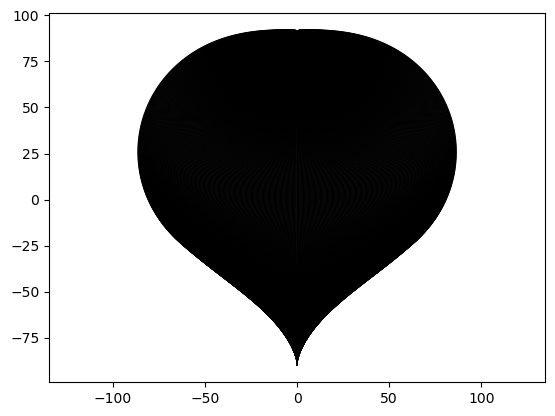

In [58]:

# MATLAB: plot(X,Y); hold on; plot(-X,Y)
plt.plot(Xp, Yp, color='black', linewidth=0.7)
plt.plot(-Xp, Yp, color='black', linewidth=0.7)
plt.axis('equal')
plt.show()

In [ ]:
'''
X= zeros(181,361);
Y= zeros(181,361);
k=1.7;
for A=1:1:181
	for B=1:1:361
		Y(A,B)=sind(k*(91-A)/2)*90/sind(k*45);
		X(A,B)=cosd(91-A)/cosd(k*(91-A)/2)*(B-1)/2;
	end
end


for i=0:1:18
	plot(X(1+i*10,:),Y(1+i*10,:),'black')
	hold on	
	plot(-X(1+i*10,:),Y(1+i*10,:),'black')
end
for i=0:1:18
	plot(X(:,1+i*20),Y(:,1+i*20),'black')
	hold on	
	plot(-X(:,1+i*20),Y(:,1+i*20),'black')
end
'''